In [2]:
import numpy as np 
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings('ignore')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6

In [3]:
os.chdir('E:\\ML Notes\\MLJan 26 Day 20 Projects\\PRJ Stock Price Prediction')

In [4]:
pwd

'E:\\ML Notes\\MLJan 26 Day 20 Projects\\PRJ Stock Price Prediction'

In [5]:
df =pd.read_csv("prices.csv", header=0)
display (df)

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0
...,...,...,...,...,...,...,...
851259,2016-12-30,ZBH,103.309998,103.199997,102.849998,103.930000,973800.0
851260,2016-12-30,ZION,43.070000,43.040001,42.689999,43.310001,1938100.0
851261,2016-12-30,ZTS,53.639999,53.529999,53.270000,53.740002,1701200.0
851262,2016-12-30 00:00:00,AIV,44.730000,45.450001,44.410000,45.590000,1380900.0


In [6]:
print(df.shape)

(851264, 7)


In [7]:
print(df.columns)

Index(['date', 'symbol', 'open', 'close', 'low', 'high', 'volume'], dtype='str')


In [8]:
print (df.symbol.value_counts())

symbol
A       1762
AAL     1762
AAP     1762
AAPL    1762
ABC     1762
        ... 
PYPL     378
HPE      304
CSRA     284
WLTW     251
FTV      126
Name: count, Length: 501, dtype: int64


In [9]:
print (df.symbol.unique())

<StringArray>
['WLTW',    'A',  'AAL',  'AAP', 'AAPL',  'ABC',  'ABT',  'ACN', 'ADBE',
  'ADI',
 ...
  'CFG', 'NAVI', 'QRVO',  'SYF',  'WRK',  'KHC', 'PYPL',  'HPE', 'CSRA',
  'FTV']
Length: 501, dtype: str


In [10]:
display(df.symbol.unique().shape)

(501,)

In [11]:
print (df.symbol.unique()[0:20])

<StringArray>
['WLTW',    'A',  'AAL',  'AAP', 'AAPL',  'ABC',  'ABT',  'ACN', 'ADBE',
  'ADI',  'ADM',  'ADP',  'ADS', 'ADSK',  'AEE',  'AEP',  'AES',  'AET',
  'AFL',  'AGN']
Length: 20, dtype: str


In [12]:
print(len(df.symbol.values))

851264


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  str    
 1   symbol  851264 non-null  str    
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), str(2)
memory usage: 45.5 MB


In [14]:
display (df.describe())

,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [15]:
display (df.isnull().sum())

date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

In [16]:
display (df.date.unique())

<StringArray>
['2016-01-05 00:00:00', '2016-01-06 00:00:00', '2016-01-07 00:00:00',
 '2016-01-08 00:00:00', '2016-01-11 00:00:00', '2016-01-12 00:00:00',
 '2016-01-13 00:00:00', '2016-01-14 00:00:00', '2016-01-15 00:00:00',
 '2016-01-19 00:00:00',
 ...
          '2016-12-16',          '2016-12-19',          '2016-12-20',
          '2016-12-21',          '2016-12-22',          '2016-12-23',
          '2016-12-27',          '2016-12-28',          '2016-12-29',
          '2016-12-30']
Length: 3524, dtype: str

In [17]:
display (pd.DataFrame(df.date.unique()))

,0
0,2016-01-05 00:00:00
1,2016-01-06 00:00:00
2,2016-01-07 00:00:00
3,2016-01-08 00:00:00
4,2016-01-11 00:00:00
...,...
3519,2016-12-23
3520,2016-12-27
3521,2016-12-28
3522,2016-12-29


In [18]:
display (df.duplicated().sum())

np.int64(0)

In [19]:
comp_info = pd.read_csv('securities.csv')
display (comp_info)

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",31-03-1964,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",31-12-2012,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",06-07-2011,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",31-08-2015,718877
...,...,...,...,...,...,...,...,...
500,YHOO,Yahoo Inc.,reports,Information Technology,Internet Software & Services,"Sunnyvale, California",NaN,1011006
501,YUM,Yum! Brands Inc,reports,Consumer Discretionary,Restaurants,"Louisville, Kentucky",06-10-1997,1041061
502,ZBH,Zimmer Biomet Holdings,reports,Health Care,Health Care Equipment,"Warsaw, Indiana",NaN,1136869
503,ZION,Zions Bancorp,reports,Financials,Regional Banks,"Salt Lake City, Utah",NaN,109380


In [20]:
print (comp_info["Ticker symbol"].nunique())

505


In [21]:
comp_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Ticker symbol            505 non-null    str  
 1   Security                 505 non-null    str  
 2   SEC filings              505 non-null    str  
 3   GICS Sector              505 non-null    str  
 4   GICS Sub Industry        505 non-null    str  
 5   Address of Headquarters  505 non-null    str  
 6   Date first added         307 non-null    str  
 7   CIK                      505 non-null    int64
dtypes: int64(1), str(7)
memory usage: 31.7 KB


In [22]:
print (comp_info.isnull().sum())

Ticker symbol                0
Security                     0
SEC filings                  0
GICS Sector                  0
GICS Sub Industry            0
Address of Headquarters      0
Date first added           198
CIK                          0
dtype: int64


In [23]:
print (comp_info.describe())

                CIK
count  5.050000e+02
mean   7.074490e+05
std    5.144375e+05
min    1.800000e+03
25%    8.631200e+04
50%    8.310010e+05
75%    1.075531e+06
max    1.659166e+06


In [ ]:
#Search for Particular company details 

In [24]:
display(comp_info.loc[comp_info.Security.str.startswith('Face') , :])

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
181,FB,Facebook,reports,Information Technology,Internet Software & Services,"Menlo Park, California",23-12-2013,1326801


In [ ]:
#Example – Search for another company - Acc

In [25]:
display (comp_info.loc[comp_info.Security.str.startswith('Acc') , :])

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",06-07-2011,1467373


In [ ]:
#Select any 6 companies 

In [26]:
comp_plot = comp_info.loc[(comp_info["Security"] == 'Yahoo Inc.') | (comp_info["Security"] == 'Xerox Corp.') | (comp_info["Security"] == 'Adobe Systems Inc')
              | (comp_info["Security"] == 'Microsoft Corp.') | (comp_info["Security"] == 'Adobe Systems Inc') 
              | (comp_info["Security"] == 'Facebook') | (comp_info["Security"] == 'Goldman Sachs Group') , ["Ticker symbol"] ]["Ticker symbol"] 
print(comp_plot)

6      ADBE
181      FB
212      GS
306    MSFT
496     XRX
500    YHOO
Name: Ticker symbol, dtype: str


In [ ]:
#For Loop to display 6 Company names 

In [27]:
for i in comp_plot:
    print (i)

ADBE
FB
GS
MSFT
XRX
YHOO


In [ ]:
#Create a function to plot Graphs for selected companies  opening stock and closing stock against time 

In [39]:
def plotter(code):
    global closing_stock ,opening_stock
    f, axs = plt.subplots(2,2,figsize=(15,8))
    plt.subplot(212)
    company = df[df['symbol']==code]
    company = company.open.values.astype('float32')
    company = company.reshape(-1, 1)
    opening_stock = company
    plt.grid(True)
    plt.xlabel('Time')
    plt.ylabel(code + " open stock prices") 
    plt.title('prices Vs Time') 
    plt.plot(company , 'g') 
    plt.subplot(211)
    company_close = df[df['symbol']==code]
    company_close = company_close.close.values.astype('float32')
    company_close = company_close.reshape(-1, 1)
    closing_stock = company_close
    plt.xlabel('Time')
    plt.ylabel(code + " close stock prices")
    plt.title('prices Vs Time')
    plt.grid(True) 
    plt.plot(company_close , 'b') 
    plt.show()stocks= np.array (df[df.symbol.isin (['YHOO'])].close)
print(stocks)



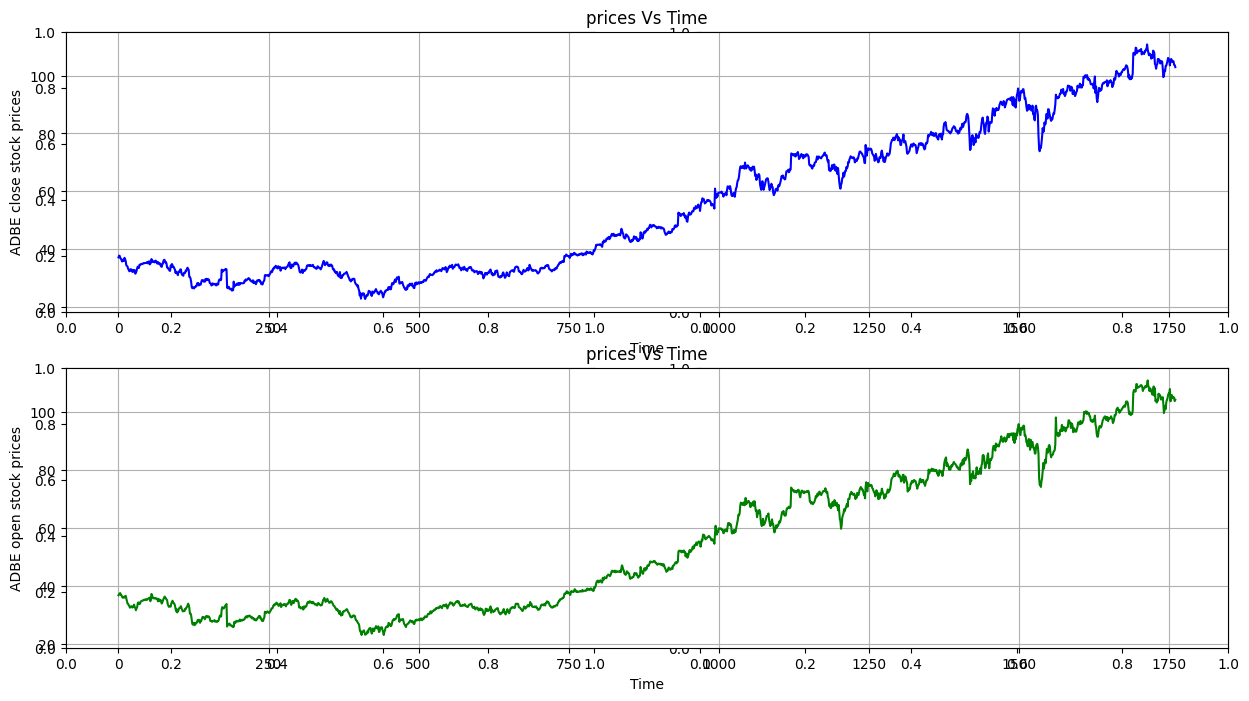

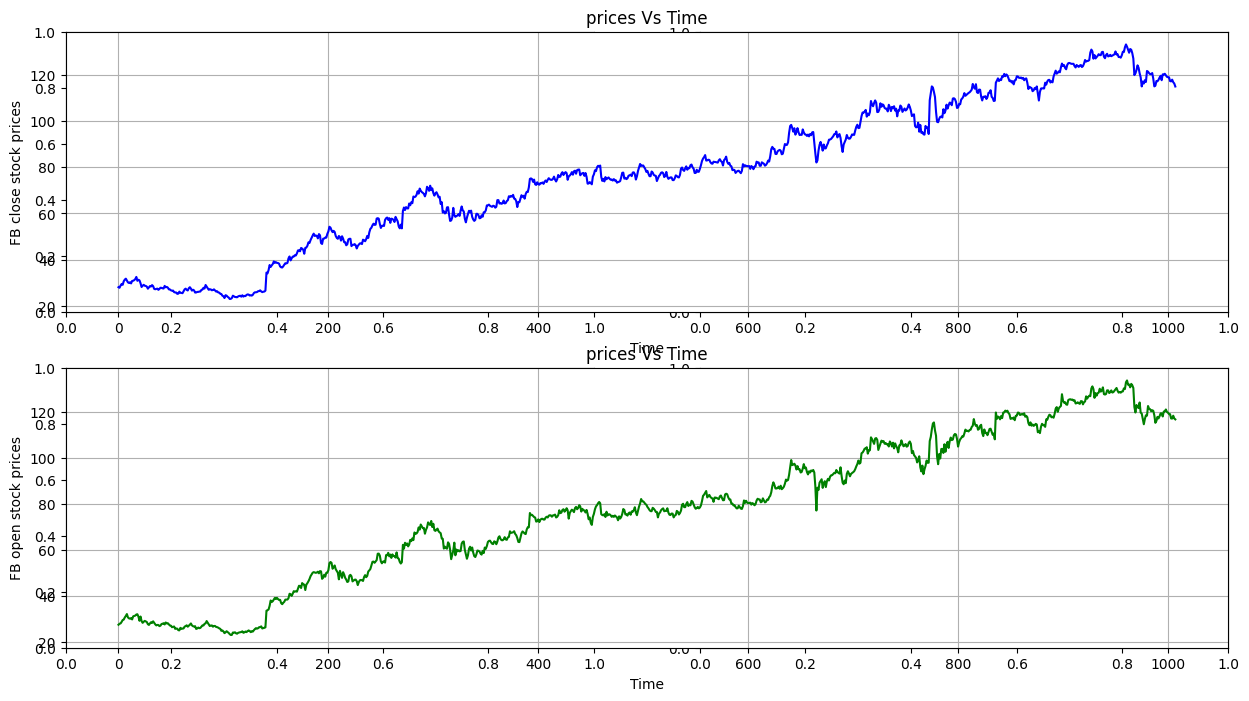

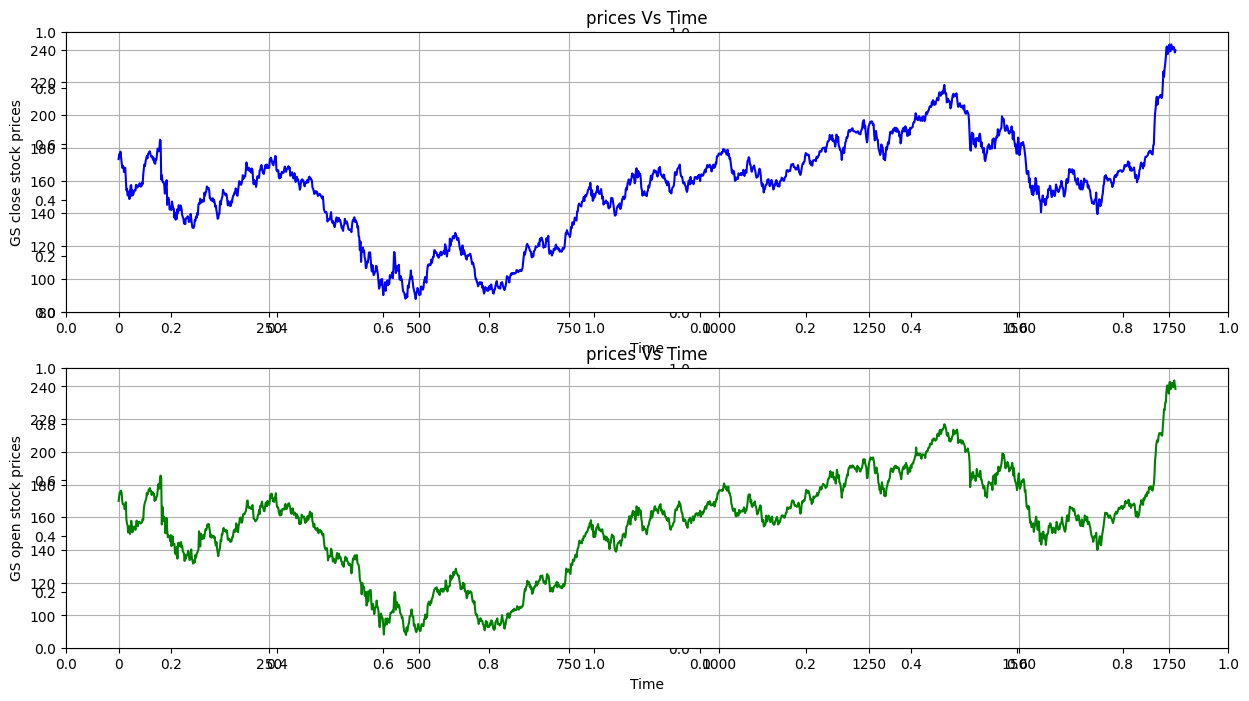

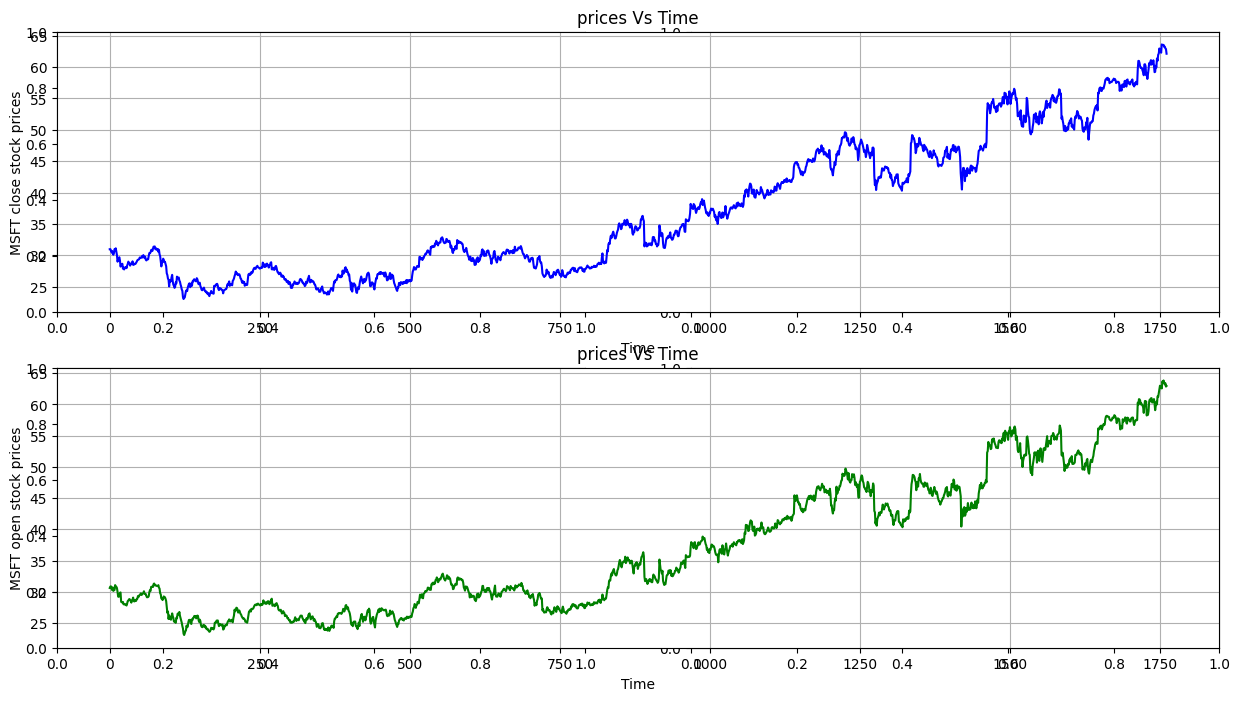

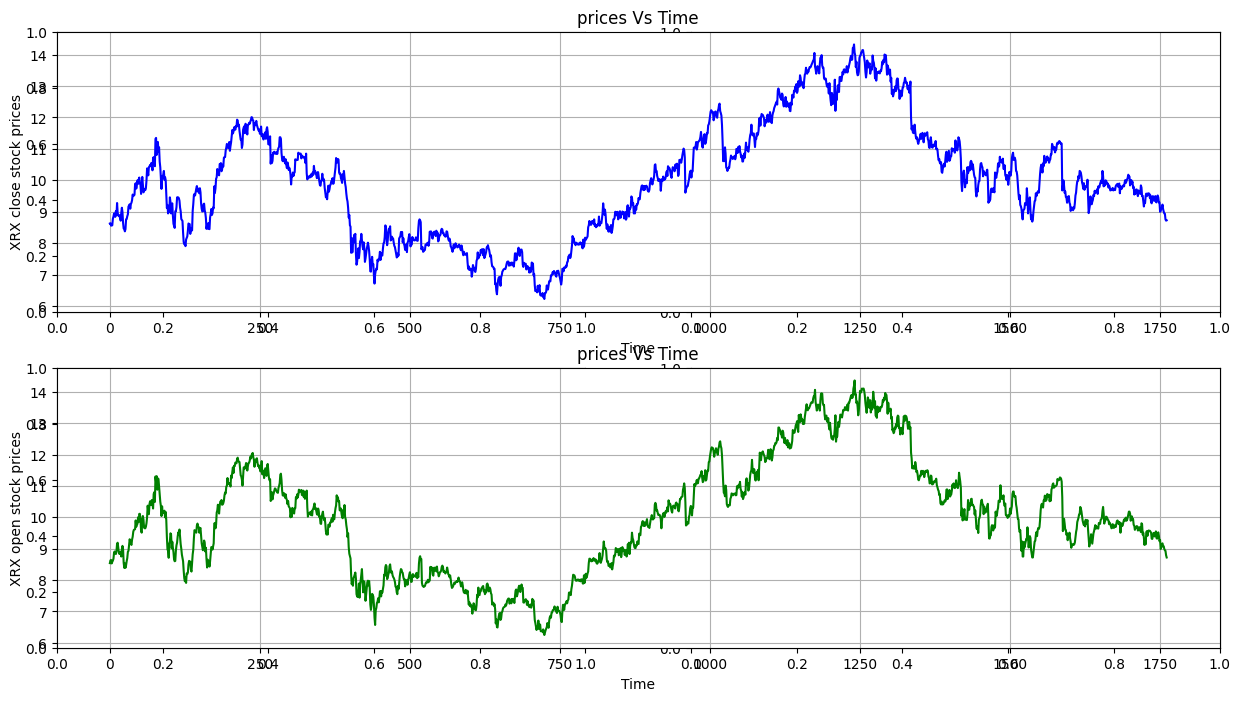

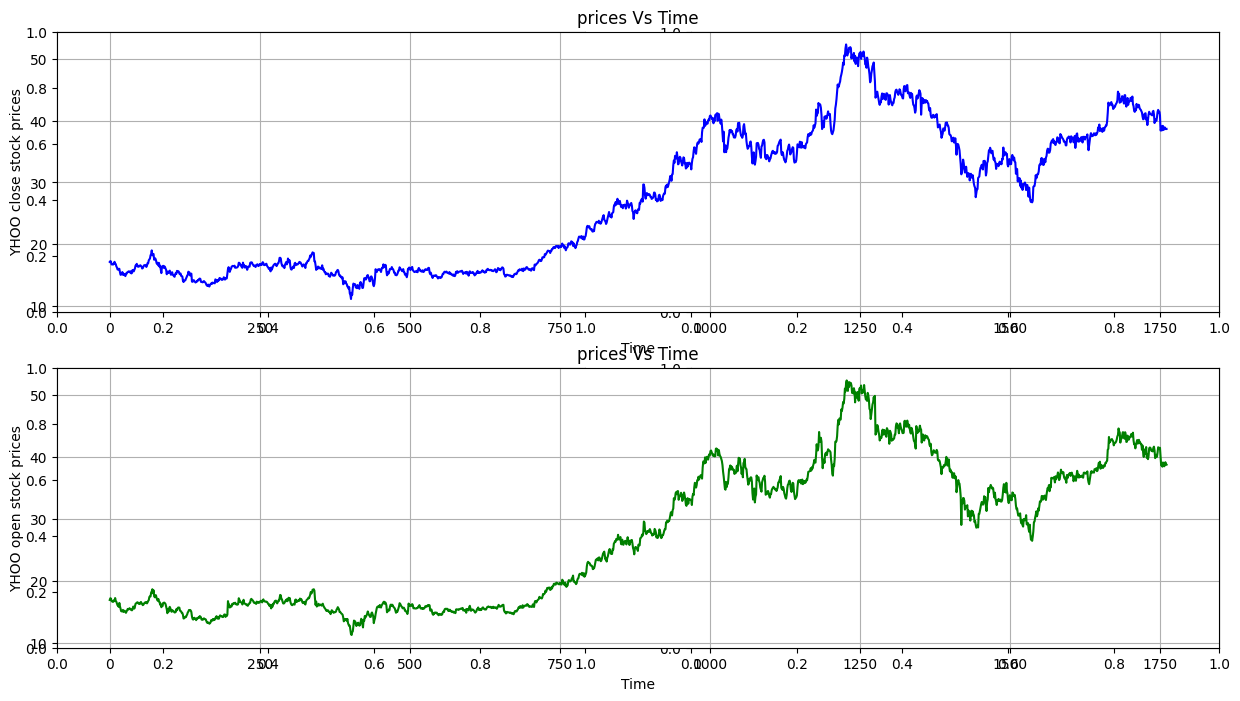

In [40]:
for i in comp_plot:
    plotter(i)


In [ ]:
#Extract closing stock of one company, here YHOO

In [41]:
stocks= np.array (df[df.symbol.isin (['YHOO'])].close)
print(stocks)

[17.1      17.23     17.17     ... 38.73     38.639999 38.669998]


In [42]:
display (stocks.shape)

(1762,)

In [ ]:
#Convert stock to 2D array     

In [43]:
stocks = stocks.reshape(len(stocks) , 1)
print (stocks.shape)
print(stocks)

(1762, 1)
[[17.1     ]
 [17.23    ]
 [17.17    ]
 ...
 [38.73    ]
 [38.639999]
 [38.669998]]


In [44]:
#Min Max Scaler      

In [45]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1)) 
stocks = scaler.fit_transform(stocks) 
display (stocks)


array([[0.14559109],
       [0.14874031],
       [0.14728683],
       ...,
       [0.66957366],
       [0.6673934 ],
       [0.66812012]], shape=(1762, 1))

In [46]:
print (stocks.shape) 

(1762, 1)


In [47]:
train = int(len(stocks) * 0.80)
print (train)


1409


In [48]:
test = len(stocks) - train 
print (test)


353


In [49]:
#Training Data

In [50]:
train = stocks[0:train]
display (train.shape)
print(train)


(1409, 1)

[[0.14559109]
 [0.14874031]
 [0.14728683]
 ...
 [0.63372095]
 [0.61458332]
 [0.61967051]]


In [51]:
#Test Data

In [52]:
test = stocks[len(train) : ]
display(test.shape)
display (test)

(353, 1)

array([[0.63129851],
       [0.60416666],
       [0.56686053],
       [0.6017442 ],
       [0.60925394],
       [0.60586237],
       [0.59593022],
       [0.58381782],
       [0.55741276],
       [0.52906978],
       [0.48982557],
       [0.50024226],
       [0.51913761],
       [0.54748061],
       [0.53415697],
       [0.51235471],
       [0.49685079],
       [0.500969  ],
       [0.51962213],
       [0.49636629],
       [0.47989342],
       [0.4949128 ],
       [0.48594962],
       [0.49273257],
       [0.46584303],
       [0.48328492],
       [0.49200583],
       [0.48062017],
       [0.47601745],
       [0.48643412],
       [0.46778102],
       [0.45179265],
       [0.44210272],
       [0.43701549],
       [0.39995156],
       [0.41593993],
       [0.43168606],
       [0.43168606],
       [0.47529068],
       [0.47868218],
       [0.48134689],
       [0.50339151],
       [0.51550386],
       [0.51913761],
       [0.52737407],
       [0.51477714],
       [0.50872094],
       [0.542

In [53]:
#Function to prepare the data, use two previous values to predict for third data 

In [ ]:
#Call the function to prepare training data

In [105]:
def process_data(data , n_features):
    dataX, dataY = [], [] 
    for i in range(len(data)-n_features):
        a = data[i:(i+n_features), 0]
        dataX.append(a) 
        dataY.append(data[i + n_features, 0])
    return np.array(dataX), np.array(dataY)

In [106]:
n_features = 10
trainX, trainY = process_data(train, n_features)
print(trainX.shape , trainY.shape)

(1399, 10) (1399,)


In [57]:
#Call the function to prepare test data 

In [58]:
n_features = 10
testX, testY = process_data(test, n_features)
print (testX.shape , testY.shape)

(343, 10) (343,)


In [59]:
#Call the function to prepare full  data 

In [61]:
n_features = 10
stocksX, stocksY = process_data(stocks, n_features)
print (stocksX.shape , stocksY.shape)

(1752, 10) (1752,)


In [62]:
#Display the First 10 Records from Train X 

In [63]:
display (trainX[:10])

array([[0.14559109, 0.14874031, 0.14728683, 0.13590119, 0.13590119,
        0.13687016, 0.13541667, 0.14074613, 0.14607561, 0.13880814],
       [0.14874031, 0.14728683, 0.13590119, 0.13590119, 0.13687016,
        0.13541667, 0.14074613, 0.14607561, 0.13880814, 0.13711241],
       [0.14728683, 0.13590119, 0.13590119, 0.13687016, 0.13541667,
        0.14074613, 0.14607561, 0.13880814, 0.13711241, 0.1281492 ],
       [0.13590119, 0.13590119, 0.13687016, 0.13541667, 0.14074613,
        0.14607561, 0.13880814, 0.13711241, 0.1281492 , 0.12378879],
       [0.13590119, 0.13687016, 0.13541667, 0.14074613, 0.14607561,
        0.13880814, 0.13711241, 0.1281492 , 0.12378879, 0.11603682],
       [0.13687016, 0.13541667, 0.14074613, 0.14607561, 0.13880814,
        0.13711241, 0.1281492 , 0.12378879, 0.11603682, 0.11555233],
       [0.13541667, 0.14074613, 0.14607561, 0.13880814, 0.13711241,
        0.1281492 , 0.12378879, 0.11603682, 0.11555233, 0.11870155],
       [0.14074613, 0.14607561, 0.1388081

In [64]:
#Display the First 10 Records from TrainY

In [65]:
display (trainY[:10])

array([0.13711241, 0.1281492 , 0.12378879, 0.11603682, 0.11555233,
       0.11870155, 0.11845931, 0.10537791, 0.09496124, 0.09593023])

In [66]:
#Reshape to 3D array to use for LSTM /Deep Learning model 

In [67]:
trainX = trainX.reshape(trainX.shape[0] , 1 ,trainX.shape[1])
display (trainX.shape)

(1399, 1, 10)

In [68]:
#Reshape to 3D array test X 

In [69]:
testX = testX.reshape(testX.shape[0] , 1 ,testX.shape[1])
display (testX.shape)

(343, 1, 10)

In [70]:
#Reshape to 3D array  full data set 

In [71]:
stocksX= stocksX.reshape(stocksX.shape[0] , 1 ,stocksX.shape[1])
display (stocksX.shape)

(1752, 1, 10)

In [72]:
#Import Libraries 

In [76]:
import math 
from keras.models import Sequential 
from keras.layers import Dense , BatchNormalization , Dropout , Activation 
from keras.layers import LSTM , GRU 
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_squared_error 
from keras.optimizers import Adam , SGD , RMSprop

In [77]:
#Create Check Points 

In [78]:
filepath="stock_weights1.keras"
from keras.callbacks import ReduceLROnPlateau , ModelCheckpoint
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.1, min_delta =0.0001, patience=1, verbose=1)
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=True, mode='max')

In [79]:
#Create the model – Fully connected Layer 

In [80]:
model = Sequential()
model.add(GRU(256 , input_shape = (1 , n_features) , return_sequences=True))
model.add(Dropout(0.4))
model.add(LSTM(256))
model.add(Dropout(0.4))
model.add(Dense(64 ,  activation = 'relu'))
model.add(Dense(1))
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 256)         │       205,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,649 (2.85 MB)

 Trainable params: 747,649 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

None


In [81]:
#Compile the Model 

In [82]:
model.compile(loss='mean_squared_error', optimizer=Adam( 0.0005) , metrics = ['mean_squared_error'])

In [83]:
#Fit the Model 

In [84]:
history = model.fit(trainX, trainY, epochs=100 , batch_size = 128 , 
          callbacks = [checkpoint , lr_reduce] , validation_data = (testX,testY))  

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1435 - mean_squared_error: 0.1435
Epoch 1: val_loss improved from None to 0.01008, saving model to stock_weights1.keras

Epoch 1: finished saving model to stock_weights1.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - loss: 0.0971 - mean_squared_error: 0.0971 - val_loss: 0.0101 - val_mean_squared_error: 0.0101 - learning_rate: 5.0000e-04
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0111 - mean_squared_error: 0.0111
Epoch 2: val_loss did not improve from 0.01008
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0137 - mean_squared_error: 0.0137 - val_loss: 0.0020 - val_mean_squared_error: 0.0020 - learning_rate: 5.0000e-04
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0061 - mean_squared_error: 0.0061
Epoch 3: val_loss did not improve from 0.01008

Epoch 3: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0065 - mean_square

In [85]:
#Predict the value for testX, display top 10 records 

In [86]:
test_pred = model.predict(testX)
display (test_pred [:10])

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


array([[0.5363507 ],
       [0.5251596 ],
       [0.5162883 ],
       [0.5118112 ],
       [0.5064243 ],
       [0.49918965],
       [0.4918154 ],
       [0.48411226],
       [0.4779586 ],
       [0.4746982 ]], dtype=float32)

In [87]:
#Inverse Transform the data – Convert the data to Original form

In [88]:
test_pred = scaler.inverse_transform(test_pred)
display (test_pred [:10])

array([[33.230556],
       [32.76859 ],
       [32.402378],
       [32.217564],
       [31.995193],
       [31.696548],
       [31.392138],
       [31.074154],
       [30.820131],
       [30.68554 ]], dtype=float32)

In [89]:
#Reshape and Display Original Data 

In [90]:
testY = testY.reshape(testY.shape[0] , 1)
testY = scaler.inverse_transform(testY)
display (testY[:10])

array([[31.309999],
       [31.74    ],
       [32.52    ],
       [33.689999],
       [33.139999],
       [32.240002],
       [31.6     ],
       [31.77    ],
       [32.540001],
       [31.58    ]])

In [91]:
#Display the accuracy 

In [92]:
from sklearn.metrics import r2_score
print (r2_score(testY,test_pred))

0.6158847334835316


In [93]:
#Plot the Graph Actual and Predicted Data 

Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices


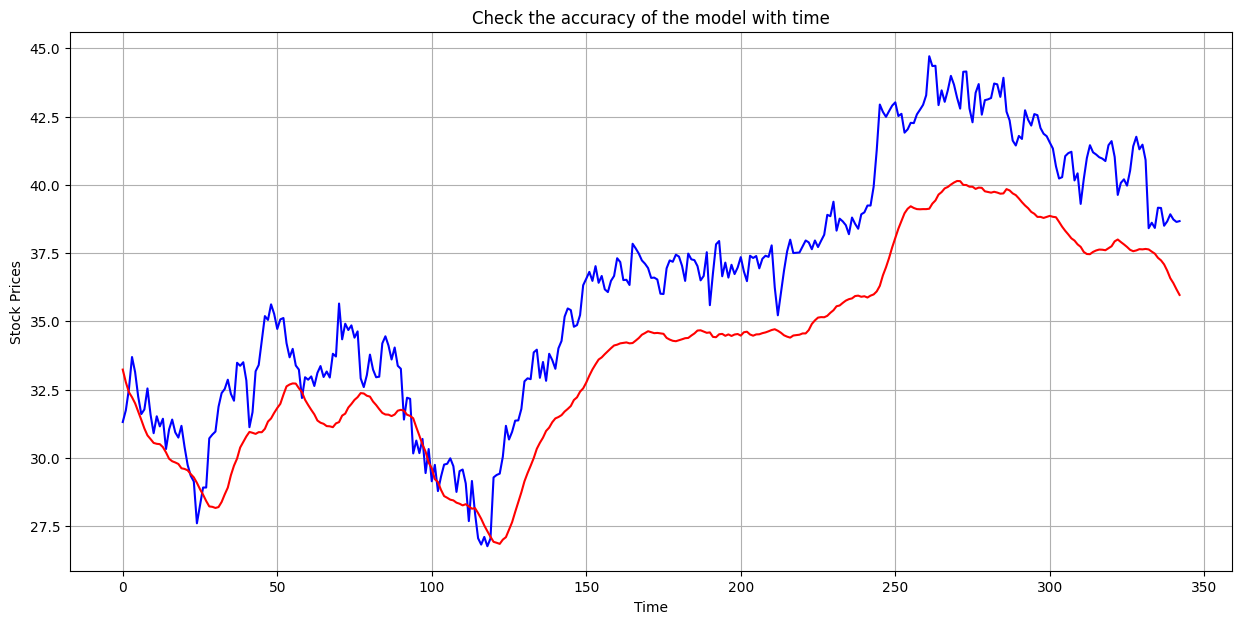

In [94]:
print("Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices")
plt.rcParams["figure.figsize"] = (15,7)
plt.plot(testY , 'b')
plt.plot(test_pred , 'r')
plt.xlabel('Time')
plt.ylabel('Stock Prices')
plt.title('Check the accuracy of the model with time')
plt.grid(True)
plt.show()

In [95]:
#Prediction Training Data and Check Accuracy 

In [96]:
train_pred = model.predict(trainX)
train_pred = scaler.inverse_transform(train_pred)
trainY = trainY.reshape(trainY.shape[0] , 1)
trainY = scaler.inverse_transform(trainY)
print ('Display Accuracy Training Data')
display (r2_score(trainY,train_pred))

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Display Accuracy Training Data


0.9605686198130532

In [97]:
#Plot the Graph 

Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices


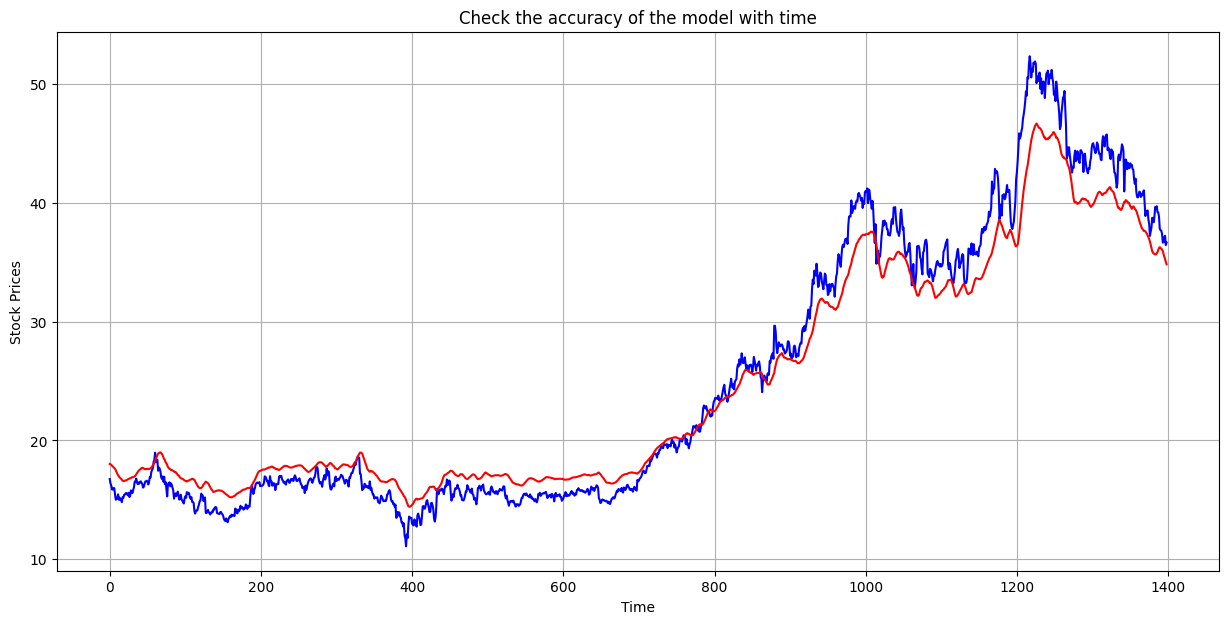

In [98]:
print("Red - Predicted Stock Prices  ,  Blue - Actual Stock Prices")
plt.rcParams["figure.figsize"] = (15,7)
plt.plot(trainY  , 'b')
plt.plot(train_pred, 'r')
plt.xlabel('Time')
plt.ylabel('Stock Prices')
plt.title('Check the accuracy of the model with time')
plt.grid(True)
plt.show()

In [99]:
#Prediction Full Data 

In [100]:
stocks_pred = model.predict(stocksX)
stocks_pred = scaler.inverse_transform(stocks_pred)
stocksY = stocksY.reshape(stocksY.shape[0] , 1)
stocksY = scaler.inverse_transform(stocksY)
print ('Display Accuracy Training Data')
display (r2_score(stocksY,stocks_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Display Accuracy Training Data


0.9563307151919339

In [101]:
#Plot the Graph 

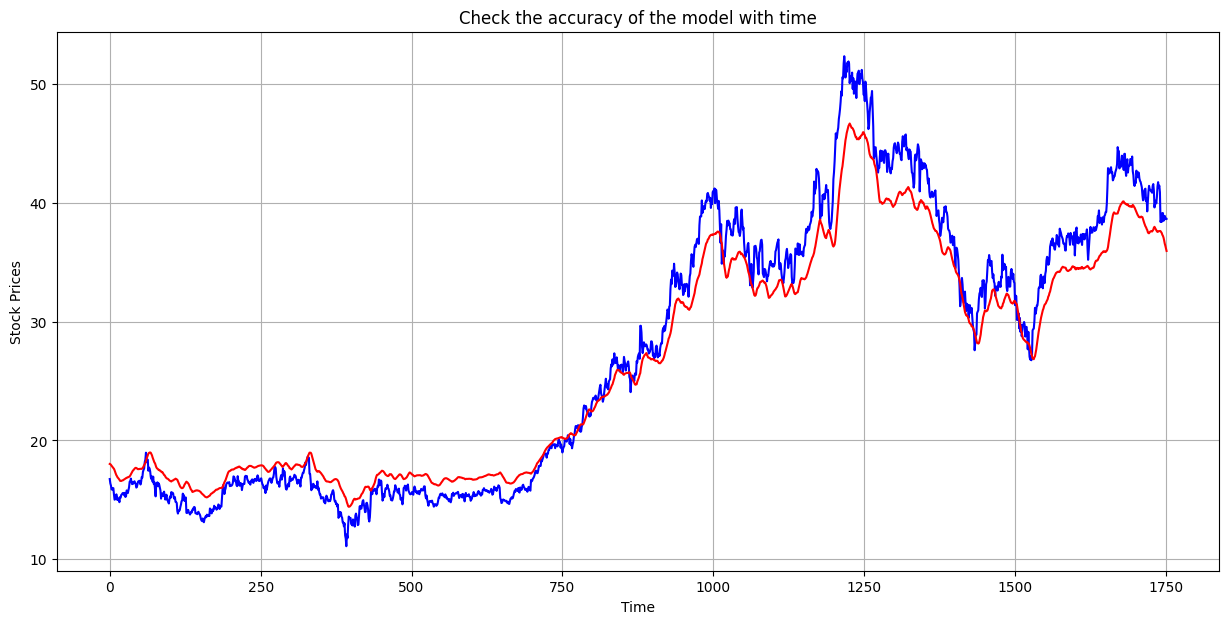

In [102]:
plt.rcParams["figure.figsize"] = (15,7)
plt.plot(stocksY  , 'b')
plt.plot(stocks_pred, 'r')
plt.xlabel('Time')
plt.ylabel('Stock Prices')
plt.title('Check the accuracy of the model with time')
plt.grid(True)
plt.show()

In [103]:
#Concat original and prediction data  

In [104]:
results= df[df.symbol.isin (['YHOO'])]
results= results [10:]
results = results.reset_index(drop=True)
df_stocks_pred= pd.DataFrame(stocks_pred, columns = ['Close_Prediction'])
results= pd.concat([results,df_stocks_pred],axis =1)
results.to_csv('results.csv')
display(results)

,date,symbol,open,close,low,high,volume,Close_Prediction
0,2010-01-19,YHOO,16.780001,16.750000,16.639999,16.959999,15182600.0,18.021542
1,2010-01-20,YHOO,16.650000,16.379999,16.250000,16.680000,14419500.0,18.000313
2,2010-01-21,YHOO,16.389999,16.200001,16.100000,16.580000,21858400.0,17.943064
3,2010-01-22,YHOO,16.080000,15.880000,15.810000,16.209999,25132800.0,17.869114
4,2010-01-25,YHOO,16.070000,15.860000,15.740000,16.110001,19683700.0,17.803511
...,...,...,...,...,...,...,...,...
1747,2016-12-23,YHOO,38.459999,38.660000,38.369999,38.810001,3840100.0,36.855831
1748,2016-12-27,YHOO,38.590000,38.919998,38.500000,39.070000,4240300.0,36.578663
1749,2016-12-28,YHOO,39.119999,38.730000,38.709999,39.220001,4393500.0,36.397476
1750,2016-12-29,YHOO,38.759998,38.639999,38.480000,38.930000,4170200.0,36.172760
